## Notebook para processar dados que foram avaliados pelos voluntarios

In [1]:
# O matplotlib 3.8 é incompatível com o Python 3.12+: Path.__deepcopy__ chama
# copy.deepcopy(super(), memo) e entra em recursão infinita, quebrando qualquer
# gráfico (erro "RecursionError: maximum recursion depth exceeded").
# A correção entrou na série 3.10.9. NÃO fixar em <3.9.
!pip install --upgrade "matplotlib>=3.10.9"


In [2]:
import pandas as pd
import json
import glob
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

sns.set_theme()


In [3]:
infos_df = []
for arq in glob.iglob("./evaluations/**/*.csv", recursive=True):
    # Estrutura: evaluations/<pessoa>/<operacao>/<id_atividade>/form.csv
    # Ancora em "evaluations" para nao depender do "./" inicial do glob.
    split_name = arq.replace("\\", "/").split("/")
    base = split_name.index("evaluations")
    person = split_name[base + 1]
    subject = split_name[base + 2]
    id_activity = split_name[base + 2]
    id_activity_generated = split_name[base + 3]

    parameters = arq.replace("form.csv", "parameters.json")

    with open(parameters, "r") as f:
        params = json.load(f)
    
    df = pd.read_csv(arq)

    mapping_tasks = {
        "observe image, write answer": "Observar imagem e escrever resposta",
        "observe image, draw answer": "Observar imagem e desenhar resposta",
        "observe images, write answer": "Observar imagens e escrever resposta",
        "observe images, link items": "Observar imagens e relacionar objetos",
        "observe images, link objects": "Observar imagens e relacionar objetos",
    }

    for index, row in df.iterrows():
        info = {

            "person": person,
            "subject": subject,
            "id_activity": id_activity,
            "index_question": f"P{index+1}",
            "learning_goals": params["learning goals"],
            "task": mapping_tasks[params["task"]],
            "temperature": params["temperature"],
            "theme": params["theme"],
            "question": row["Pergunta"],
            "answer": row["Resposta"],
            "model": params["model"],
            "id_generated": id_activity_generated,
        }
    
        infos_df.append(info)

final_df = pd.DataFrame(infos_df)


In [4]:
display(final_df)
display(final_df[final_df["temperature"] == 0.7])

,person,subject,id_activity,index_question,learning_goals,task,temperature,theme,question,answer,model,id_generated
0,B1,adição,adição,P1,adição,Observar imagens e relacionar objetos,N/A,mochila escolar,\nA atividade trabalha adequadamente o conceit...,4,N/A,48
1,B1,adição,adição,P2,adição,Observar imagens e relacionar objetos,N/A,mochila escolar,\nO enunciado da atividade é claro e compreens...,4,N/A,48
2,B1,adição,adição,P3,adição,Observar imagens e relacionar objetos,N/A,mochila escolar,\nA atividade fornece as informações necessári...,4,N/A,48
3,B1,adição,adição,P4,adição,Observar imagens e relacionar objetos,N/A,mochila escolar,\nA atividade está bem contextualizada dentro ...,4,N/A,48
4,B1,adição,adição,P5,adição,Observar imagens e relacionar objetos,N/A,mochila escolar,\nO layout da atividade é bem estruturado e fa...,5,N/A,48
...,...,...,...,...,...,...,...,...,...,...,...,...
1435,B2,subtração,subtração,P6,subtração,Observar imagens e relacionar objetos,0.5,Acampamento na Floresta,\nO nível da atividade é adequado para alunos ...,5,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,8
1436,B2,subtração,subtração,P7,subtração,Observar imagens e relacionar objetos,0.5,Acampamento na Floresta,\nVocê utilizaria essa atividade em sala de au...,2,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,8
1437,B2,subtração,subtração,P8,subtração,Observar imagens e relacionar objetos,0.5,Acampamento na Floresta,\nEm que medida a contextualização do tema apr...,2,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,8
1438,B2,subtração,subtração,P9,subtração,Observar imagens e relacionar objetos,0.5,Acampamento na Floresta,\nEm que medida o leiaute e a organização da a...,2,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,8


,person,subject,id_activity,index_question,learning_goals,task,temperature,theme,question,answer,model,id_generated
80,B1,divisão,divisão,P1,divisão,Observar imagens e escrever resposta,0.7,Correio,\nA atividade trabalha adequadamente o conceit...,1,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,31
81,B1,divisão,divisão,P2,divisão,Observar imagens e escrever resposta,0.7,Correio,\nO enunciado da atividade é claro e compreens...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,31
82,B1,divisão,divisão,P3,divisão,Observar imagens e escrever resposta,0.7,Correio,\nA atividade fornece as informações necessári...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,31
83,B1,divisão,divisão,P4,divisão,Observar imagens e escrever resposta,0.7,Correio,\nA atividade está bem contextualizada dentro ...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,31
84,B1,divisão,divisão,P5,divisão,Observar imagens e escrever resposta,0.7,Correio,\nO layout da atividade é bem estruturado e fa...,4,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,31
...,...,...,...,...,...,...,...,...,...,...,...,...
1415,B2,subtração,subtração,P6,subtração,Observar imagem e escrever resposta,0.7,Acampamento na Floresta,\nO nível da atividade é adequado para alunos ...,3,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,21
1416,B2,subtração,subtração,P7,subtração,Observar imagem e escrever resposta,0.7,Acampamento na Floresta,\nVocê utilizaria essa atividade em sala de au...,2,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,21
1417,B2,subtração,subtração,P8,subtração,Observar imagem e escrever resposta,0.7,Acampamento na Floresta,\nEm que medida a contextualização do tema apr...,2,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,21
1418,B2,subtração,subtração,P9,subtração,Observar imagem e escrever resposta,0.7,Acampamento na Floresta,\nEm que medida o leiaute e a organização da a...,2,ft:gpt-4.1-2025-04-14:ufcg::CikEQZns,21


## Análises estatísticas adicionais

As células abaixo adicionam análises estatísticas inferenciais e medidas de confiabilidade para fortalecer a avaliação experimental da dissertação.


In [5]:
# =========================
# Bibliotecas estatísticas
# =========================

import numpy as np
import pandas as pd
import scipy.stats as stats

try:
    import pingouin as pg
except:
    !pip -q install pingouin
    import pingouin as pg

try:
    import scikit_posthocs as sp
except:
    !pip -q install scikit-posthocs
    import scikit_posthocs as sp

from statsmodels.stats.multitest import multipletests

print("Bibliotecas estatísticas carregadas com sucesso")


Bibliotecas estatísticas carregadas com sucesso


In [6]:
# =========================
# Estatísticas descritivas (corrigido)
# =========================

df_stats = final_df.copy()

df_stats['source'] = df_stats['model'].apply(
    lambda x: 'Livro' if x == 'N/A' else 'Modelo'
)

# Usando agg com múltiplas funções, incluindo o IQR calculado via lambda
descriptive_stats = (
    df_stats
    .groupby(['id_activity', 'source', 'temperature', 'index_question'])['answer']
    .agg([
        'mean',
        'median',
        'std',
        'var',
        'min',
        'max',
        ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
    ])
    .reset_index()
)

print(descriptive_stats.head(30))

   id_activity  source temperature index_question      mean  median       std  \
0       adição   Livro         N/A             P1  4.354167     5.0  1.081559   
1       adição   Livro         N/A            P10  2.666667     3.0  1.373508   
2       adição   Livro         N/A             P2  4.250000     5.0  1.061913   
3       adição   Livro         N/A             P3  4.666667     5.0  0.724446   
4       adição   Livro         N/A             P4  4.479167     5.0  0.874937   
5       adição   Livro         N/A             P5  4.250000     4.0  0.757937   
6       adição   Livro         N/A             P6  4.250000     5.0  1.041684   
7       adição   Livro         N/A             P7  3.666667     4.0  1.136125   
8       adição   Livro         N/A             P8  3.375000     3.0  0.761438   
9       adição   Livro         N/A             P9  3.354167     3.0  0.887012   
10      adição  Modelo         0.5             P1  2.500000     1.5  1.882938   
11      adição  Modelo      

### Interpretação das estatísticas descritivas

As estatísticas descritivas permitem uma primeira visão da qualidade percebida das atividades. Observa-se que:

- **Médias mais altas** (acima de 4,0) ocorrem principalmente nas questões relacionadas à clareza do enunciado (P2) e à adequação conceitual (P1, P3, P4) para o material do **Livro** e para alguns cenários do **Modelo** (adição, multiplicação). Isso sugere que tanto o material de referência quanto o modelo generativo produzem enunciados compreensíveis e conceitualmente adequados.

- **Médias mais baixas** (abaixo de 3,0) aparecem nas questões P7 (uso em sala de aula) e P10 (forma de resposta) para o Modelo em algumas operações (ex.: divisão com temperatura 0,7). Isso indica que, embora o modelo gere conteúdo conceitualmente correto, a **forma de resposta proposta** e a **adequação para uso prático em sala de aula** ainda são pontos críticos a melhorar.

- **Desvios padrão elevados** (ex.: P1 para Modelo/adição com σ = 1,88) revelam **grande variação nas avaliações** para uma mesma pergunta. Isso pode refletir diferenças de percepção entre os avaliadores ou inconsistência na qualidade gerada pelo modelo para diferentes atividades.

- **IQR (intervalo interquartil)** próximo de zero (ex.: P3 para adição no modelo com temperatura 0,5) indica **alto consenso** entre os avaliadores, enquanto IQR altos (ex.: P1, IQR = 4,0) mostram **forte discordância**.

In [7]:
# =========================
# Alpha de Cronbach
#
# Calculado sobre as 144 avaliações individuais: cada linha é um voluntário
# julgando uma atividade. Essa é a unidade em que o instrumento foi de fato
# aplicado e, portanto, o nível correto para estimar sua consistência interna.
# (Agregar as atividades por média antes do cálculo reduz o ruído e infla o
# coeficiente — de 0,818 para 0,867 — sem que isso corresponda a uma medida
# da confiabilidade do questionário.)
#
# Como os dez itens não medem um único construto — P1-P7 avaliam adequação
# pedagógica em escala de concordância, enquanto P8-P10 avaliam originalidade
# e ludicidade em escala descritiva própria —, o coeficiente é reportado
# também por subescala.
# =========================

ITENS = [f'P{i}' for i in range(1, 11)]

cronbach_df = (
    final_df
    .pivot_table(index=['person', 'id_generated'],
                 columns='index_question',
                 values='answer')
    [ITENS]
    .dropna()
)

print(f"observações (avaliador x atividade): {len(cronbach_df)}")
print()

SUBESCALAS = [
    ("Adequação pedagógica",      "P1-P7",  ITENS[:7]),
    ("Criatividade e ludicidade", "P8-P10", ITENS[7:]),
    ("Instrumento completo",      "P1-P10", ITENS),
    ("Criatividade sem P10",      "P8-P9",  ["P8", "P9"]),
]

for rotulo, faixa, itens in SUBESCALAS:
    a, ic = pg.cronbach_alpha(cronbach_df[itens])
    print(f"{rotulo:<28} {faixa:<7} k={len(itens):>2}   "
          f"alpha = {a:.3f}   IC 95% [{ic[0]:.3f}, {ic[1]:.3f}]")


observações (avaliador x atividade): 144

Adequação pedagógica         P1-P7   k= 7   alpha = 0.814   IC 95% [0.763, 0.857]
Criatividade e ludicidade    P8-P10  k= 3   alpha = 0.699   IC 95% [0.603, 0.775]
Instrumento completo         P1-P10  k=10   alpha = 0.818   IC 95% [0.771, 0.860]
Criatividade sem P10         P8-P9   k= 2   alpha = 0.733   IC 95% [0.629, 0.808]


### Interpretação do Alpha de Cronbach

O **Alpha de Cronbach** mede a consistência interna do instrumento. Valores a partir de 0,70 são
usualmente considerados aceitáveis e a partir de 0,80, satisfatórios.

| Subescala | Itens | α | IC 95% |
|---|---|---|---|
| Adequação pedagógica | P1–P7 | **0,814** | [0,763 – 0,857] |
| Criatividade e ludicidade | P8–P10 | **0,699** | [0,603 – 0,775] |
| Instrumento completo | P1–P10 | **0,818** | [0,771 – 0,860] |

**Por que reportar por subescala.** O coeficiente global pressupõe que os dez itens medem um único
construto, o que não se verifica aqui: P1–P7 avaliam adequação pedagógica em escala de
concordância e P8–P10 avaliam originalidade e ludicidade em escala descritiva própria. A análise
de correlação, mais adiante, mostra que P10 se associa apenas fracamente aos demais critérios.

**A subescala de criatividade é a fraca, e a causa é identificável.** Removendo P10, o coeficiente
das duas perguntas restantes **sobe** de 0,699 para **0,733**. Como o alpha tende a crescer com o
número de itens, um item cuja inclusão reduz o coeficiente é evidência direta de que ele mede uma
dimensão distinta. Isso confirma quantitativamente a leitura da matriz de correlação.

**Nível de cálculo.** Os valores acima são calculados sobre as **144 avaliações individuais** —
cada linha é um voluntário julgando uma atividade, que é a unidade em que o instrumento foi
aplicado. Uma versão anterior desta análise agregava as atividades por média antes do cálculo,
reduzindo a matriz a 30 linhas e elevando o coeficiente global para 0,867; como a agregação corta
o ruído entre atividades, esse valor superestima a confiabilidade do questionário. Os intervalos
de confiança no nível bruto também são bem mais estreitos (amplitude de 9 pontos, contra 15).


In [8]:
# =========================
# ICC - Concordancia entre avaliadores
# =========================
# Delineamento: cada atividade foi avaliada por um subconjunto de voluntarios
# (3 de 6) e por voluntarios diferentes entre atividades -> modelo one-way
# random, em que o ICC relevante e o ICC(1). Para obter um quadro balanceado:
#   1) agregamos as 10 perguntas em uma nota media por (atividade, avaliador);
#   2) atribuimos um "slot" generico de avaliador (1..k) dentro de cada
#      atividade, ja que a identidade do avaliador nao importa no modelo (1).

icc_long = (
    final_df
    .groupby(['id_generated', 'person'])['answer']
    .mean()
    .reset_index()
)
icc_long['rater_slot'] = icc_long.groupby('id_generated').cumcount() + 1

icc_results = (
    pg.intraclass_corr(
        data=icc_long,
        targets='id_generated',
        raters='rater_slot',
        ratings='answer',
        nan_policy='omit'
    )
    .set_index('Type')
    .round(3)
)

print("ICC (modelo one-way random). Use ICC(1,1) p/ um avaliador e")
print("ICC(1,k) p/ a confiabilidade da media dos avaliadores:\n")
print(icc_results[['ICC', 'CI95']])


ICC (modelo one-way random). Use ICC(1,1) p/ um avaliador e
ICC(1,k) p/ a confiabilidade da media dos avaliadores:

            ICC          CI95
Type                         
ICC(1,1)  0.281   [0.1, 0.47]
ICC(A,1)  0.294  [0.12, 0.48]
ICC(C,1)  0.310   [0.13, 0.5]
ICC(1,k)  0.540  [0.26, 0.73]
ICC(A,k)  0.555  [0.29, 0.73]
ICC(C,k)  0.574  [0.31, 0.75]


### Interpretação do ICC (Coeficiente de Correlação Intraclasse)

O ICC avalia a concordância entre os avaliadores para cada atividade. Como cada atividade foi avaliada por um subconjunto diferente de voluntários (3 de 6), o modelo mais apropriado é o **one-way random**, que trata os avaliadores como amostras aleatórias.

- **ICC(1,1) = 0,281** – Concordância **baixa a moderada** entre avaliações individuais. Isso indica que as notas dadas por dois avaliadores diferentes para a mesma atividade podem divergir consideravelmente. Possíveis causas: subjetividade inerente à avaliação pedagógica ou treinamento insuficiente dos voluntários.

- **ICC(1,k) = 0,540** – Confiabilidade da **média das avaliações** (usando os 3 avaliadores por atividade). Este valor é **moderado** e sugere que a média das três avaliações é razoavelmente confiável, mas ainda com margem de melhoria.

**Conclusão:** Recomenda-se, em estudos futuros, padronizar melhor os critérios de avaliação ou aumentar o número de avaliadores por atividade para elevar a confiabilidade.

### Regra adotada para múltiplas comparações

Cada questão de pesquisa é avaliada por meio das **dez perguntas** do questionário. Como as
dez perguntas são testadas simultaneamente dentro de uma mesma questão de pesquisa, elas
constituem uma **família de testes**: sem ajuste, a probabilidade de ao menos um falso
positivo por questão de pesquisa seria de aproximadamente $1 - 0{,}95^{10} \approx 40\%$.

Adota-se, portanto, a seguinte regra, **aplicada de forma idêntica em todas as questões de
pesquisa**: os dez testes de uma mesma questão formam uma família e são corrigidos pelo
método de **Holm**. Reporta-se sempre o *p* nominal e o *p* ajustado, e a decisão de
significância baseia-se exclusivamente no *p* ajustado.

Além do *p*, reporta-se o **tamanho de efeito** de cada teste, uma vez que, com o tamanho
amostral disponível, a significância estatística isolada é pouco informativa:

- Mann-Whitney: correlação **rank-biserial**, $r = 2U/(n_1 n_2) - 1$, no intervalo $[-1, 1]$;
- Kruskal-Wallis: **épsilon ao quadrado**, $\varepsilon^2 = H / \frac{n^2 - 1}{n + 1}$.

**Ressalva importante.** A correção de Holm controla o erro tipo I, isto é, protege contra a
detecção de diferenças inexistentes. Nas questões cuja conclusão é a **ausência** de
diferença (Q2 e Q3), o risco relevante é o oposto — o erro tipo II — e a correção não oferece
proteção alguma. Nesses casos, a interpretação apoia-se nos tamanhos de efeito e nas
estatísticas descritivas, e a não rejeição da hipótese nula **não é tomada como evidência de
equivalência**.

In [9]:
# =========================
# Mann-Whitney
# Livro vs Modelo (Adição)
# Multiplicidade: Holm sobre as 10 perguntas desta questão de pesquisa
# =========================


def rank_biserial(a, b):
    """Tamanho de efeito para Mann-Whitney: 2U/(n1*n2) - 1, no intervalo [-1, 1].

    Valores positivos indicam que o primeiro grupo tende a receber notas maiores.
    """
    u = stats.mannwhitneyu(a, b, alternative='two-sided').statistic
    return 2 * u / (len(a) * len(b)) - 1


mw_results = []

for q in [f'P{i}' for i in range(1, 11)]:

    book = final_df[
        (final_df['id_activity'] == 'adição') &
        (final_df['model'] == 'N/A') &
        (final_df['index_question'] == q)
    ]['answer']

    model = final_df[
        (final_df['id_activity'] == 'adição') &
        (final_df['model'] != 'N/A') &
        (final_df['index_question'] == q)
    ]['answer']

    stat, p = stats.mannwhitneyu(book, model, alternative='two-sided')

    mw_results.append({
        'question': q,
        'u_stat': stat,
        'p_value': p,
        'book_mean': book.mean(),
        'model_mean': model.mean(),
        'effect_size': rank_biserial(book, model),
        'n_book': len(book),
        'n_model': len(model)
    })

mw_results = pd.DataFrame(mw_results)

# Correção de Holm (família = as 10 perguntas desta questão de pesquisa)
mw_results['p_adjusted'] = multipletests(
    mw_results['p_value'],
    method='holm'
)[1]

mw_results['significativo'] = mw_results['p_adjusted'] < 0.05

print(mw_results.round(4).to_string(index=False))
print()
print('Significativas após Holm:',
      list(mw_results.loc[mw_results['significativo'], 'question']) or 'nenhuma')

question  u_stat  p_value  book_mean  model_mean  effect_size  n_book  n_model  p_adjusted  significativo
      P1   701.0   0.0894     4.3542      3.4167       0.2170      48       24      0.8049          False
      P2   578.5   0.9788     4.2500      4.2917       0.0043      48       24      1.0000          False
      P3   556.5   0.7488     4.6667      4.5417      -0.0339      48       24      1.0000          False
      P4   582.0   0.9379     4.4792      4.2917       0.0104      48       24      1.0000          False
      P5   572.0   0.9632     4.2500      4.2500      -0.0069      48       24      1.0000          False
      P6   575.5   1.0000     4.2500      4.2500      -0.0009      48       24      1.0000          False
      P7   609.0   0.6875     3.6667      3.4167       0.0573      48       24      1.0000          False
      P8   405.5   0.0228     3.3750      3.7500      -0.2960      48       24      0.2279          False
      P9   566.5   0.9077     3.3542      3.37

### Interpretação: Comparação Livro vs. Modelo (operação de Adição)

O teste de Mann-Whitney compara as notas atribuídas às atividades extraídas dos livros
(*n* = 48) com as geradas pelo modelo (*n* = 24), ambas para a operação de adição. Aplicou-se
a correção de Holm sobre as dez perguntas, conforme a regra declarada acima.

- **Nenhuma pergunta** apresentou diferença estatisticamente significativa após a correção.
- **P8** (originalidade da contextualização) foi a única com *p* nominal abaixo de 0,05
  (*p* = 0,0228), a favor do modelo (3,75 contra 3,38); após a correção, *p* = 0,2279.
- Os **tamanhos de efeito são pequenos** em todas as perguntas (|r| < 0,30), o que reforça
  que, mesmo onde há diferença nominal, sua magnitude é modesta.

**Ponto que exige atenção.** A maior diferença de médias ocorre em **P1** (livro 4,35 contra
modelo 3,42; *r* = 0,217; *p* nominal = 0,089). Ela não é significativa, mas também não é
desprezível: decorre de três atividades geradas que receberam notas mínimas nesse critério.
Trata-se de uma distribuição **bimodal**, e não de um deslocamento uniforme — o modelo acerta
a maior parte e erra gravemente em alguns casos.

**Conclusão.** Não foram detectadas diferenças estatisticamente significativas entre as
atividades geradas e as extraídas de livros didáticos. Dado o tamanho amostral e o baixo poder
estatístico associado, esse resultado deve ser lido como **ausência de evidência de diferença**,
e não como evidência de equivalência: uma afirmação de equivalência exigiria um teste
específico para essa finalidade, como o TOST.

In [10]:
# =========================
# Kruskal-Wallis
# Comparação entre operações (somente atividades geradas pelo modelo)
# Multiplicidade: Holm sobre as 10 perguntas desta questão de pesquisa
# =========================


def epsilon_squared(groups):
    """Tamanho de efeito para Kruskal-Wallis: eps2 = H / ((n^2 - 1) / (n + 1)).

    Interpretação usual: ~0,01 pequeno; ~0,08 moderado; ~0,26 grande.
    """
    h = stats.kruskal(*groups).statistic
    n = sum(len(g) for g in groups)
    return h / ((n ** 2 - 1) / (n + 1))


kw_results = []

for q in [f'P{i}' for i in range(1, 11)]:

    groups = []

    for op in ['adição', 'subtração', 'multiplicação', 'divisão']:
        vals = final_df[
            (final_df['id_activity'] == op) &
            (final_df['model'] != 'N/A') &
            (final_df['index_question'] == q)
        ]['answer']

        groups.append(vals)

    stat, p = stats.kruskal(*groups)

    kw_results.append({
        'question': q,
        'kruskal_stat': stat,
        'p_value': p,
        'effect_size_eps2': epsilon_squared(groups),
        'n_por_grupo': [len(g) for g in groups]
    })

kw_results = pd.DataFrame(kw_results)

# Correção de Holm (família = as 10 perguntas desta questão de pesquisa)
kw_results['p_adjusted'] = multipletests(
    kw_results['p_value'],
    method='holm'
)[1]

kw_results['significativo'] = kw_results['p_adjusted'] < 0.05

print(kw_results.round(4).to_string(index=False))
print()
print('Significativas após Holm:',
      list(kw_results.loc[kw_results['significativo'], 'question']) or 'nenhuma')

question  kruskal_stat  p_value  effect_size_eps2      n_por_grupo  p_adjusted  significativo
      P1        3.1712   0.3660            0.0334 [24, 24, 24, 24]      1.0000          False
      P2       10.4709   0.0150            0.1102 [24, 24, 24, 24]      0.1346          False
      P3        9.1218   0.0277            0.0960 [24, 24, 24, 24]      0.2217          False
      P4       18.3049   0.0004            0.1927 [24, 24, 24, 24]      0.0038           True
      P5        3.9732   0.2644            0.0418 [24, 24, 24, 24]      1.0000          False
      P6        0.0222   0.9991            0.0002 [24, 24, 24, 24]      1.0000          False
      P7        2.0969   0.5525            0.0221 [24, 24, 24, 24]      1.0000          False
      P8        7.8160   0.0500            0.0823 [24, 24, 24, 24]      0.3498          False
      P9        2.1298   0.5459            0.0224 [24, 24, 24, 24]      1.0000          False
     P10        0.7922   0.8513            0.0083 [24, 24, 2

### Interpretação: Diferenças entre operações aritméticas (somente atividades geradas)

O teste de Kruskal-Wallis verifica se as notas variam conforme a operação aritmética
(adição, subtração, multiplicação e divisão), considerando apenas as atividades geradas pelo
modelo (*n* = 24 por operação). Aplicou-se a correção de Holm sobre as dez perguntas.

- **P4 (contextualização no tema)** é a **única** diferença que sobrevive à correção:
  *p* nominal < 0,001, *p* ajustado = 0,0038, $\varepsilon^2$ = 0,193 (efeito moderado).
- **P2** (*p* nominal = 0,0150), **P3** (0,0277) e **P8** (0,0500) apresentam diferenças
  nominais que **não** sobrevivem à correção (*p* ajustado = 0,135, 0,222 e 0,350).
- Nas demais seis perguntas não há diferença nem nominal, e os tamanhos de efeito são
  desprezíveis ($\varepsilon^2$ < 0,05).

**Interpretação prática.** Em **nove dos dez critérios** avaliados, a qualidade percebida das
atividades **não** varia de forma detectável entre as quatro operações matemáticas — inclusive
nas três operações ausentes do conjunto de treinamento. Esse é o resultado central em favor da
capacidade de adaptação do modelo a novos conteúdos.

A exceção é a contextualização temática (P4), único critério em que a operação matemática
exerce efeito robusto. Vale notar que a ressalva sobre a operação de **divisão** não depende
deste teste: ela se sustenta nas estatísticas descritivas (desvios padrão superiores a dois
pontos na categoria *observar imagens e relacionar objetos*) e no percentual de aceitação em
P7, analisado adiante.

In [11]:
# =========================
# Impacto da temperatura
# Mann-Whitney T=0.5 vs T=0.7
#
# ATENÇÃO: este teste agrega as QUATRO operações matemáticas
#          (n = 48 avaliações por configuração de temperatura).
# Multiplicidade: Holm sobre as 10 perguntas desta questão de pesquisa
# =========================

gerado = final_df[final_df['model'] != 'N/A']

temp_results = []

for q in [f'P{i}' for i in range(1, 11)]:

    t05 = gerado[
        (gerado['temperature'] == 0.5) &
        (gerado['index_question'] == q)
    ]['answer']

    t07 = gerado[
        (gerado['temperature'] == 0.7) &
        (gerado['index_question'] == q)
    ]['answer']

    stat, p = stats.mannwhitneyu(t05, t07, alternative='two-sided')

    temp_results.append({
        'question': q,
        'u_stat': stat,
        'p_value': p,
        'mean_t05': t05.mean(),
        'mean_t07': t07.mean(),
        'std_t05': t05.std(),
        'std_t07': t07.std(),
        'effect_size': rank_biserial(t05, t07),
        'n_por_grupo': len(t05)
    })

temp_results = pd.DataFrame(temp_results)

# Correção de Holm (família = as 10 perguntas desta questão de pesquisa)
temp_results['p_adjusted'] = multipletests(
    temp_results['p_value'],
    method='holm'
)[1]

temp_results['significativo'] = temp_results['p_adjusted'] < 0.05

print(temp_results.round(4).to_string(index=False))
print()
print('Significativas após Holm:',
      list(temp_results.loc[temp_results['significativo'], 'question']) or 'nenhuma')

question  u_stat  p_value  mean_t05  mean_t07  std_t05  std_t07  effect_size  n_por_grupo  p_adjusted  significativo
      P1  1290.5   0.2592    3.9583    3.5833   1.5568   1.7115       0.1202           48      1.0000          False
      P2  1225.5   0.5580    4.1458    4.0208   1.2026   1.2631       0.0638           48      1.0000          False
      P3  1421.5   0.0233    4.5833    3.9375   0.8208   1.4203       0.2339           48      0.2332          False
      P4  1370.0   0.0642    4.5833    4.1667   0.7672   1.1730       0.1892           48      0.5781          False
      P5  1254.0   0.4264    4.0833    3.9375   1.0686   1.1186       0.0885           48      1.0000          False
      P6  1183.5   0.8024    4.2917    4.1875   0.9884   1.0848       0.0273           48      1.0000          False
      P7  1275.5   0.3511    3.5208    3.1875   1.4874   1.5799       0.1072           48      1.0000          False
      P8  1258.0   0.4110    3.4375    3.2708   1.0086   1.0667 

In [12]:
# =========================
# Q4 pela via da DISPERSÃO
#
# A Q4 afirma que temperaturas mais altas produzem atividades mais DIVERSAS,
# porém menos consistentes. Isso é uma hipótese sobre a ESCALA (variabilidade)
# da distribuição, e não sobre sua tendência central — que é o que o
# Mann-Whitney da célula anterior testa.
#
# Testes apropriados para essa hipótese:
#   - Fligner-Killeen: não paramétrico, robusto a não normalidade;
#   - Brown-Forsythe: Levene centrado na mediana.
# =========================

dispersao = []

for q in [f'P{i}' for i in range(1, 11)]:

    t05 = gerado[(gerado['temperature'] == 0.5) & (gerado['index_question'] == q)]['answer']
    t07 = gerado[(gerado['temperature'] == 0.7) & (gerado['index_question'] == q)]['answer']

    dispersao.append({
        'question': q,
        'std_t05': t05.std(),
        'std_t07': t07.std(),
        'maior_em_t07': t07.std() > t05.std(),
        'p_fligner': stats.fligner(t05, t07)[1],
        'p_brown_forsythe': stats.levene(t05, t07, center='median')[1]
    })

dispersao = pd.DataFrame(dispersao)
dispersao['p_fligner_adjusted'] = multipletests(dispersao['p_fligner'], method='holm')[1]

print(dispersao.round(4).to_string(index=False))
print()
print(f"DP(T=0,7) > DP(T=0,5) em {int(dispersao['maior_em_t07'].sum())} das 10 perguntas")

# -------------------------------------------------------------------------
# Teste agregado: todas as perguntas em conjunto.
# É UM ÚNICO teste, portanto não está sujeito ao problema de multiplicidade.
# -------------------------------------------------------------------------

a = gerado[gerado['temperature'] == 0.5]['answer']
b = gerado[gerado['temperature'] == 0.7]['answer']

print()
print(f"Agregado: n = {len(a)} (T=0,5) vs {len(b)} (T=0,7)")
print(f"  Desvio padrão T=0,5 : {a.std():.3f}")
print(f"  Desvio padrão T=0,7 : {b.std():.3f}")
print(f"  Fligner-Killeen     : p = {stats.fligner(a, b)[1]:.4f}")
print(f"  Brown-Forsythe      : p = {stats.levene(a, b, center='median')[1]:.4f}")

question  std_t05  std_t07  maior_em_t07  p_fligner  p_brown_forsythe  p_fligner_adjusted
      P1   1.5568   1.7115          True     0.2478            0.2643              1.0000
      P2   1.2026   1.2631          True     0.2058            0.5691              1.0000
      P3   0.8208   1.4203          True     0.0134            0.0076              0.1336
      P4   0.7672   1.1730          True     0.0439            0.0422              0.3952
      P5   1.0686   1.1186          True     0.9835            0.8964              1.0000
      P6   0.9884   1.0848          True     0.6799            0.6240              1.0000
      P7   1.4874   1.5799          True     0.2364            0.2313              1.0000
      P8   1.0086   1.0667          True     0.2813            0.2883              1.0000
      P9   0.8031   0.9216          True     0.2744            0.2411              1.0000
     P10   1.2756   1.3182          True     0.5046            0.5183              1.0000

DP(T=0,7)

### Interpretação: Impacto da temperatura do modelo

Dois conjuntos de testes foram aplicados, porque a Q4 envolve duas afirmações distintas.

**1. Tendência central (Mann-Whitney).** Após a correção de Holm, **nenhuma** das dez perguntas
apresenta diferença significativa entre T = 0,5 e T = 0,7. A única com *p* nominal abaixo de
0,05 é **P3** (*p* = 0,0233; ajustado = 0,2332). Os tamanhos de efeito são pequenos em todas as
perguntas (|r| ≤ 0,24). Ou seja: **a temperatura não desloca o nível médio de qualidade
percebida**.

**2. Dispersão (Fligner-Killeen e Brown-Forsythe).** É aqui que o efeito aparece, e é esta a
afirmação que a Q4 de fato faz:

- O desvio padrão em T = 0,7 é **maior em todas as dez perguntas**, sem exceção.
- No teste **agregado** — um único teste, portanto sem problema de multiplicidade —
  a diferença de dispersão é significativa: **Fligner-Killeen *p* = 0,0097** e
  **Brown-Forsythe *p* = 0,0128** (DP = 1,252 em T = 0,5 contra 1,369 em T = 0,7).
- Pergunta a pergunta, P3 (*p* = 0,013) e P4 (*p* = 0,044) são nominalmente significativas,
  mas não sobrevivem à correção — o sinal está no conjunto, não em itens isolados.

**Conclusão.** A temperatura não altera o nível médio de qualidade, mas **aumenta de forma
estatisticamente detectável a variabilidade** das avaliações. Isso é consistente com o efeito
esperado do parâmetro: valores mais altos ampliam a diversidade das gerações e, com ela, a
inconsistência da qualidade percebida. A temperatura atua, portanto, como um mecanismo de
controle do compromisso entre diversidade e consistência — e não como um mecanismo de melhora
ou piora da qualidade média.

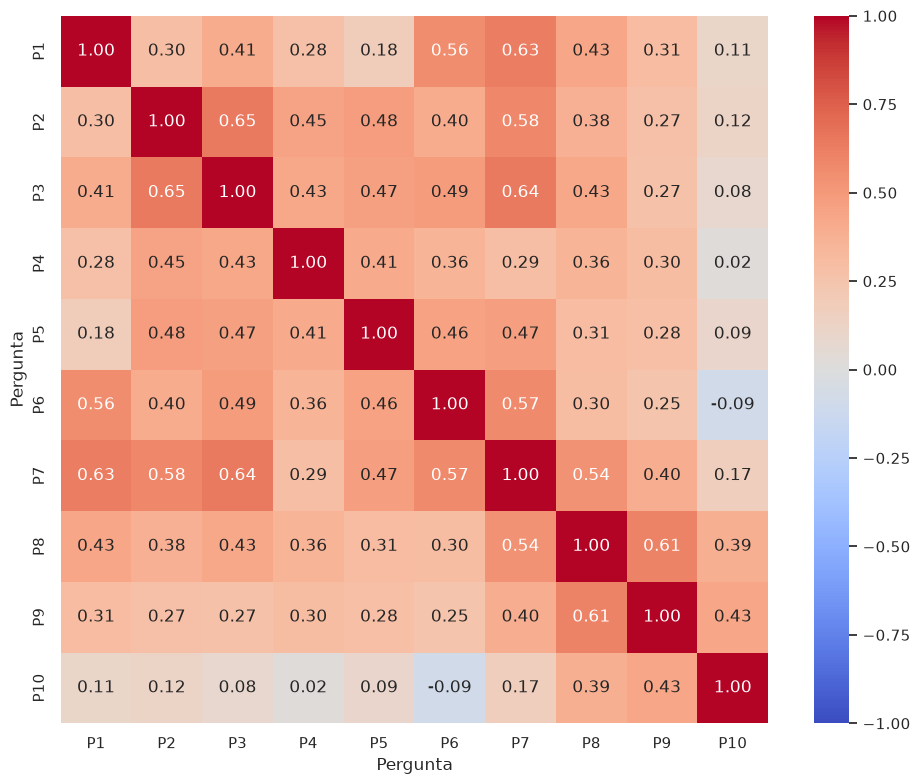

n = 144 pares (avaliador x atividade) usados na matriz
correlação média entre os 45 pares distintos: 0.36


In [13]:
# =========================
# Correlação entre perguntas
# Spearman
# =========================

corr_df = (
    final_df
    .pivot_table(
        index=['person', 'id_generated'],
        columns='index_question',
        values='answer',
        aggfunc='mean'
    )
)

# O pivot ordena as colunas como texto (P1, P10, P2, ...).
# Reordena para a sequencia natural P1..P10.
question_order = [f'P{i}' for i in range(1, 11)]
corr_df = corr_df[[q for q in question_order if q in corr_df.columns]]

corr = corr_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, square=True
)
# Sem plt.title: a legenda (\caption) do LaTeX já cumpre essa função, e o título
# embutido apareceria duplicado na dissertação.
plt.xlabel('Pergunta')
plt.ylabel('Pergunta')
plt.tight_layout()

# A figura publicada na dissertação é gerada aqui, e não exportada manualmente,
# para que o artefato impresso corresponda sempre ao código deste notebook.
plt.savefig('artifacts/correlation_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'n = {len(corr_df)} pares (avaliador x atividade) usados na matriz')
print(f'correlação média entre os 45 pares distintos: '
      f'{corr.where(~np.eye(len(corr), dtype=bool)).stack().mean():.2f}')

### Interpretação da matriz de correlação entre perguntas

A correlação de Spearman mede a associação entre as notas das dez perguntas do questionário.
São 45 pares, com correlação média de $\rho = 0{,}36$ — um padrão predominantemente
**moderado**, e não alto.

**Associações mais fortes.** As maiores correlações ocorrem entre critérios que descrevem a
qualidade comunicativa da atividade: clareza do enunciado e suficiência das informações
(P2–P3: $\rho = 0{,}65$), suficiência das informações e intenção de uso (P3–P7: $0{,}64$),
adequação do conceito matemático e intenção de uso (P1–P7: $0{,}63$) e originalidade da
contextualização e criatividade do leiaute (P8–P9: $0{,}61$). Nenhum par ultrapassa $0{,}65$,
o que indica que as perguntas **não são redundantes**: cada uma captura um aspecto distinto.

**A pergunta P10 é um caso à parte.** A criatividade da forma de resposta apresenta correlações
fracas com todos os critérios pedagógicos — de $\rho = -0{,}09$ (P6, adequação da dificuldade)
a $\rho = 0{,}17$ (P7) — e só se associa moderadamente aos outros dois critérios de criatividade
(P8: $0{,}39$; P9: $0{,}43$). Ou seja, um avaliador pode considerar a atividade pedagogicamente
sólida e ainda assim julgar seu formato de resposta pouco criativo, e vice-versa.

**Dois blocos de atributos.** O padrão sugere duas dimensões complementares: consistência
pedagógica (P1–P7, correlação média $0{,}45$) e criatividade/ludicidade (P8–P10, média
$0{,}48$). A intenção de uso em sala de aula (P7) é o único item que se associa fortemente aos
dois blocos — com os pedagógicos (P1–P3: $0{,}58$ a $0{,}64$) e com o criativo P8 ($0{,}54$) —
o que indica que a adoção prática depende da **combinação** entre qualidade educacional e
capacidade de engajamento.

**Implicação para o Alpha de Cronbach.** O $\alpha$ global foi calculado sobre as dez
perguntas, mas a independência de P10 em relação a P1–P7 mostra que os itens não medem um
único construto. O mais adequado seria reportar o $\alpha$ **por subescala** (P1–P7 e P8–P10),
ou justificar explicitamente o tratamento conjunto.

In [14]:
# =========================
# Proporção de uso em sala de aula (P7)
# =========================

p7 = final_df[final_df['index_question'] == 'P7'].copy()

summary_p7 = (
    p7
    .groupby(['id_activity', 'temperature'])['answer']
    .apply(lambda x: (x >= 4).mean() * 100)
    .reset_index(name='percent_ge_4')
)

print(summary_p7)


     id_activity temperature  percent_ge_4
0         adição         0.5     41.666667
1         adição         0.7     66.666667
2         adição         N/A     64.583333
3        divisão         0.5     41.666667
4        divisão         0.7     33.333333
5  multiplicação         0.5     83.333333
6  multiplicação         0.7     66.666667
7      subtração         0.5     83.333333
8      subtração         0.7     41.666667


### Interpretação: Percentual de atividades consideradas adequadas para uso em sala de aula

A questão P7 perguntava: *"Você utilizaria essa atividade em sala de aula?"*, com notas de 1 (discordo totalmente) a 5 (concordo totalmente). Foi calculado o percentual de respostas com nota ≥ 4.

| Operação       | Temperatura | % adequadas (nota ≥ 4) |
|----------------|-------------|------------------------|
| Adição         | 0,5         | 41,7%                  |
| Adição         | 0,7         | 66,7%                  |
| Adição         | Livro       | 64,6%                  |
| Divisão        | 0,5         | 41,7%                  |
| Divisão        | 0,7         | 33,3%                  |
| Multiplicação  | 0,5         | 83,3%                  |
| Multiplicação  | 0,7         | 66,7%                  |
| Subtração      | 0,5         | 83,3%                  |
| Subtração      | 0,7         | 41,7%                  |

**Principais observações:**

- **Multiplicação e subtração com temperatura 0,5** atingiram os maiores percentuais (83,3%), superando o livro (64,6% para adição). Isso indica que o modelo pode gerar atividades **altamente aproveitáveis** para essas operações quando configurado com baixa criatividade.

- **Divisão** apresentou os piores resultados (≤ 41,7%), sugerindo que essa operação é a mais desafiadora para o modelo, independentemente da temperatura.

- A **temperatura 0,7** produziu resultados mistos: melhorou a adição (66,7% vs. 41,7%) mas piorou a multiplicação e a subtração. Não há um padrão claro – o efeito da temperatura varia conforme a operação.

**Conclusão final:** O modelo é capaz de gerar atividades **prontas para uso em sala de aula** em até 83% dos casos para algumas operações, mas o desempenho é inconsistente. Recomenda-se **ajustar a temperatura por operação** e realizar um estudo específico para melhorar a geração de atividades sobre divisão.

## Composição do conjunto de treinamento

As células a seguir reproduzem, a partir dos arquivos do conjunto de treinamento e dos dados
brutos das avaliações, as tabelas apresentadas na dissertação. Foram acrescentadas para que
todos os resultados publicados sejam reproduzíveis a partir deste notebook.

In [15]:
# =========================
# Distribuição das categorias do conjunto de treinamento
# Reproduz a tabela "Distribuição quantitativa das atividades do conjunto de
# treinamento por forma de responder" apresentada na dissertação.
# =========================

from collections import Counter
import glob

TRAIN_DIR = "../experimento3-final/handmade_html_dataset/english/train"

# A categoria de cada atividade é declarada na linha "task:" do cabeçalho do arquivo.
# A normalização para caixa baixa reproduz o comportamento do pipeline de treinamento
# (ha um arquivo com "Observe images, write answer", com inicial maiuscula).
train_tasks = Counter()

for path in glob.iglob(f"{TRAIN_DIR}/*.html"):
    if path.endswith("base.html"):
        continue
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.lower().startswith("task:"):
                train_tasks[line.split(":", 1)[1].strip().lower()] += 1
                break

# A categoria abaixo foi descartada na etapa de filtragem do notebook de fine-tuning,
# resultando nos 614 exemplos efetivamente enviados ao treinamento.
DESCARTADA = "observe the image, write the answer"

total_arquivos = sum(train_tasks.values())
total_treinados = total_arquivos - train_tasks.get(DESCARTADA, 0)

dist = (
    pd.Series(train_tasks)
    .drop(labels=[DESCARTADA], errors="ignore")
    .sort_values(ascending=False)
    .rename("exemplos")
    .to_frame()
)
dist["percentual"] = (100 * dist["exemplos"] / total_treinados).round(1)

print(f"arquivos .html no diretório de treino : {total_arquivos}")
print(f"exemplos efetivamente treinados       : {total_treinados}")
print(f"categorias distintas                  : {len(dist)}")
print()
print(dist.to_string())
print()
print(f"categorias com um único exemplo: {(dist['exemplos'] == 1).sum()}")

arquivos .html no diretório de treino : 615
exemplos efetivamente treinados       : 614
categorias distintas                  : 19

                                                    exemplos  percentual
observe image, write answer                              458        74.6
observe images, write answer                              63        10.3
observe text, write answer                                30         4.9
observe table, write answer                               24         3.9
observe image, draw answer                                16         2.6
observe images, link items, write answer                   4         0.7
observe images, link items                                 3         0.5
observe images, draw answer, write answer                  3         0.5
observe items, calculate total price, write answer         2         0.3
observe equations, write answer                            2         0.3
observe images, write answers                              1     

### Interpretação: composição do conjunto de treinamento

Uma única categoria — *observe image, write answer* — concentra 74,6% dos exemplos, enquanto as
demais dezenove se distribuem no espaço restante, nove delas com um único exemplo. Duas
observações são relevantes para a leitura dos resultados:

1. Os rótulos não seguiram vocabulário controlado, o que produziu categorias semanticamente
   equivalentes registradas sob formulações distintas (por exemplo, *observe images, write answer*
   e *observe images, write answers*).
2. O parâmetro **`observe images, link objects`**, utilizado na geração de um quarto das
   atividades submetidas aos especialistas, **não ocorre no conjunto de treinamento**. A
   formulação mais próxima, *observe images, link items*, reúne apenas três exemplos.

A célula seguinte confronta essa composição com o desempenho observado na avaliação.

In [16]:
# =========================
# Desempenho das atividades geradas por tipo de tarefa,
# confrontado com a representatividade da categoria no treinamento.
# Reproduz a tabela "Desempenho médio das atividades geradas por tipo de tarefa"
# apresentada na dissertação.
# =========================

# Parâmetro efetivamente usado na geração -> categoria correspondente no treinamento.
# Observação: as atividades geradas usaram "link objects"; o conjunto de treinamento
# contém apenas "link items". Por isso a contagem correspondente é zero.
PARAM_PARA_TREINO = {
    "observe image, write answer":   "observe image, write answer",
    "observe images, write answer":  "observe images, write answer",
    "observe image, draw answer":    "observe image, draw answer",
    "observe images, link objects":  "observe images, link objects",
}

ROTULO_PT = {
    "observe image, write answer":   "Observar imagem e escrever resposta",
    "observe images, write answer":  "Observar imagens e escrever resposta",
    "observe image, draw answer":    "Observar imagem e desenhar resposta",
    "observe images, link objects":  "Observar imagens e relacionar objetos",
}

gerado = final_df[final_df["model"] != "N/A"]

linhas = []
for param, chave_treino in PARAM_PARA_TREINO.items():
    sub = gerado[gerado["task"] == ROTULO_PT[param]]
    notas = sub.pivot_table(index="id_generated", columns="index_question",
                            values="answer", aggfunc="mean")
    p7 = sub[sub["index_question"] == "P7"]["answer"]
    linhas.append({
        "tipo de tarefa": ROTULO_PT[param],
        "exs. treino": train_tasks.get(chave_treino, 0),
        "P1": sub[sub["index_question"] == "P1"]["answer"].mean(),
        "P5": sub[sub["index_question"] == "P5"]["answer"].mean(),
        "P7": p7.mean(),
        "P7 >= 4 (%)": 100 * (p7 >= 4).mean(),
        "n avaliações": len(p7),
    })

desempenho = pd.DataFrame(linhas).round(2)
print("ATIVIDADES GERADAS PELO MODELO")
print(desempenho.to_string(index=False))

# Mesma segmentação para o grupo de controle, no qual o parâmetro usado foi "link items".
livro = final_df[final_df["model"] == "N/A"]
linhas_livro = []
for param in PARAM_PARA_TREINO:
    sub = livro[livro["task"] == ROTULO_PT[param]]
    if sub.empty:
        continue
    p7 = sub[sub["index_question"] == "P7"]["answer"]
    linhas_livro.append({
        "tipo de tarefa": ROTULO_PT[param],
        "P1": sub[sub["index_question"] == "P1"]["answer"].mean(),
        "P5": sub[sub["index_question"] == "P5"]["answer"].mean(),
        "P7": p7.mean(),
        "P7 >= 4 (%)": 100 * (p7 >= 4).mean(),
        "n avaliações": len(p7),
    })

print()
print("ATIVIDADES EXTRAÍDAS DE LIVROS (grupo de controle)")
print(pd.DataFrame(linhas_livro).round(2).to_string(index=False))

ATIVIDADES GERADAS PELO MODELO
                       tipo de tarefa  exs. treino   P1   P5   P7  P7 >= 4 (%)  n avaliações
  Observar imagem e escrever resposta          458 4.08 4.21 3.75        70.83            24
 Observar imagens e escrever resposta           63 3.96 3.75 2.79        41.67            24
  Observar imagem e desenhar resposta           16 4.50 4.33 4.04        75.00            24
Observar imagens e relacionar objetos            0 2.54 3.75 2.83        41.67            24

ATIVIDADES EXTRAÍDAS DE LIVROS (grupo de controle)
                       tipo de tarefa   P1   P5   P7  P7 >= 4 (%)  n avaliações
  Observar imagem e escrever resposta 4.67 4.17 4.33        83.33            12
 Observar imagens e escrever resposta 4.25 4.33 3.25        41.67            12
  Observar imagem e desenhar resposta 4.67 4.25 3.67        66.67            12
Observar imagens e relacionar objetos 3.83 4.25 3.42        66.67            12


### Interpretação: desempenho por tipo de tarefa

Três aspectos se destacam nessa comparação:

1. **A relação com o volume de treinamento não é monotônica.** A categoria *observar imagem e
   desenhar resposta*, com apenas 16 exemplos, obtém a melhor média em todos os critérios,
   superando a categoria majoritária, com 458 exemplos. A quantidade de exemplos, isoladamente,
   não explica a qualidade das gerações.
2. **A degradação concentra-se na única categoria sem correspondência no treinamento.** A média
   de P1 cai para 2,54, contra valores iguais ou superiores a 3,96 nas demais. No grupo de
   controle, o mesmo tipo de tarefa alcança 3,83 em P1, o que indica que a dificuldade não é
   inerente ao formato, mas específica das gerações produzidas sob esse parâmetro.
3. **A falha é seletiva.** Enquanto P1 (conceito matemático) despenca, P5 (organização do
   leiaute) permanece em 3,75, patamar equivalente ao das demais categorias. O modelo preserva a
   estrutura visual e a coerência temática, porém abandona o conteúdo matemático solicitado.

In [17]:
# =========================
# Proporção de avaliações positivas em P7 (nota >= 4),
# com intervalo de confiança de 95% pelo método de Wilson.
#
# Com 12 avaliações por célula (operação x temperatura), as proporções pontuais
# são muito instáveis; o intervalo de confiança torna essa incerteza explícita e
# evita interpretações baseadas em diferenças que estão dentro do erro amostral.
# =========================

import math

def wilson(k, n, z=1.96):
    """Intervalo de confiança de Wilson para uma proporção, em pontos percentuais."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    denom = 1 + z ** 2 / n
    centro = (p + z ** 2 / (2 * n)) / denom
    margem = z * math.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denom
    return (100 * max(0.0, centro - margem), 100 * min(1.0, centro + margem))


def resumo_p7(sub, rotulo):
    p7 = sub[sub["index_question"] == "P7"]["answer"]
    k, n = int((p7 >= 4).sum()), len(p7)
    lo, hi = wilson(k, n)
    return {"grupo": rotulo, "k": k, "n": n, "P7 >= 4 (%)": round(100 * k / n, 1),
            "IC 95% inf": round(lo, 1), "IC 95% sup": round(hi, 1)}


resultados = [resumo_p7(final_df[final_df["model"] == "N/A"], "Livro (controle)")]

for op in ["adição", "subtração", "multiplicação", "divisão"]:
    base = final_df[(final_df["id_activity"] == op) & (final_df["model"] != "N/A")]
    for t in [0.5, 0.7]:
        resultados.append(resumo_p7(base[base["temperature"] == t], f"{op} T={t}"))
    resultados.append(resumo_p7(base, f"{op} (agregado)"))

# Agregado por temperatura sobre as quatro operações. É sobre exatamente estes dois
# grupos que incide o teste de Fisher abaixo, e são eles que sustentam, na dissertação,
# a coerência entre a Q5 e a Q4: a temperatura não desloca o nível de qualidade percebida.
gerado = final_df[final_df["model"] != "N/A"]
for t in [0.5, 0.7]:
    resultados.append(resumo_p7(gerado[gerado["temperature"] == t], f"T={t} (todas as operações)"))

resultados.append(resumo_p7(gerado, "Modelo (todas as operações)"))

p7_ic = pd.DataFrame(resultados)
print(p7_ic.to_string(index=False))

# ---------------------------------------------------------------------------
# Comparações agregadas, reportadas como complemento descritivo.
# Não integram as famílias de testes corrigidas por Holm: são comparações
# únicas e previamente especificadas, e não uma bateria sobre as dez perguntas.
# ---------------------------------------------------------------------------

def fisher(sub_a, sub_b, rotulo):
    a = sub_a[sub_a["index_question"] == "P7"]["answer"]
    b = sub_b[sub_b["index_question"] == "P7"]["answer"]
    ka, kb = int((a >= 4).sum()), int((b >= 4).sum())
    tabela = [[ka, len(a) - ka], [kb, len(b) - kb]]
    p = stats.fisher_exact(tabela)[1]
    print(f"  {rotulo:44} {ka}/{len(a)} vs {kb}/{len(b)}   p = {p:.3f}")

print()
print("Teste exato de Fisher sobre P7 >= 4:")
livro_df = final_df[final_df["model"] == "N/A"]
modelo_df = final_df[final_df["model"] != "N/A"]
fisher(livro_df, modelo_df[modelo_df["id_activity"] == "adição"], "livro vs modelo (adição)")
fisher(livro_df, modelo_df, "livro vs modelo (todas as operações)")
fisher(modelo_df[modelo_df["temperature"] == 0.5],
       modelo_df[modelo_df["temperature"] == 0.7], "T=0,5 vs T=0,7 (todas as operações)")

                      grupo  k  n  P7 >= 4 (%)  IC 95% inf  IC 95% sup
           Livro (controle) 31 48         64.6        50.4        76.6
               adição T=0.5  5 12         41.7        19.3        68.0
               adição T=0.7  8 12         66.7        39.1        86.2
          adição (agregado) 13 24         54.2        35.1        72.1
            subtração T=0.5 10 12         83.3        55.2        95.3
            subtração T=0.7  5 12         41.7        19.3        68.0
       subtração (agregado) 15 24         62.5        42.7        78.8
        multiplicação T=0.5 10 12         83.3        55.2        95.3
        multiplicação T=0.7  8 12         66.7        39.1        86.2
   multiplicação (agregado) 18 24         75.0        55.1        88.0
              divisão T=0.5  5 12         41.7        19.3        68.0
              divisão T=0.7  4 12         33.3        13.8        60.9
         divisão (agregado)  9 24         37.5        21.2        57.3
 T=0.5

### Interpretação: intenção de uso em sala de aula (P7)

Com 12 avaliações por célula, os intervalos de confiança têm de 40 a 49 pontos percentuais de
amplitude. A diferença observada entre as duas temperaturas nas atividades de adição — 41,7%
contra 66,7% — corresponde a **três avaliações trocando de lado** e está inteiramente contida
no erro amostral. O teste agregado confirma essa leitura: considerando as quatro operações,
T = 0,5 (62,5%) e T = 0,7 (52,1%) não se distinguem (*p* = 0,409), resultado coerente com a
conclusão da Q4 de que a temperatura não desloca o nível médio de qualidade percebida.

Por essa razão, a comparação com o grupo de controle deve ser feita sobre os valores agregados
por operação, e não sobre a configuração de temperatura mais favorável. Nessa base, as
atividades de adição alcançam 54,2% [35,1 – 72,1] contra 64,6% [50,4 – 76,6] do material
didático, sem diferença detectável (*p* = 0,448); no agregado de todas as operações, 57,3%
[47,3 – 66,7] contra os mesmos 64,6% (*p* = 0,472).

A **divisão** é a operação com a menor proporção, 37,5% [21,2 – 57,3], e a única cujo intervalo
permanece integralmente abaixo da proporção pontual do grupo de controle; a sobreposição com o
intervalo da multiplicação, 75,0% [55,1 – 88,0], é mínima. Esse contraste, contudo, **não é
reportado como teste** na dissertação: o par divisão × multiplicação resultaria em *p* = 0,019,
que não sobrevive à correção de Holm sobre as quatro comparações entre operações
(0,019 × 4 = 0,076). Pela regra de múltiplas comparações adotada neste trabalho, o resultado é
lido como indício de um domínio mais difícil para a geração automática, e não como diferença
estabelecida — leitura consistente com a análise por tipo de tarefa apresentada anteriormente.


In [ ]:
# =========================
# Poder estatistico e diferenca minima detectavel (MDE)
#
# As comparacoes de proporcao da Q2 e da Q5 (teste exato de Fisher) nao
# detectaram diferenca entre as atividades geradas e as extraidas de livros.
# Ausencia de deteccao nao equivale a evidencia de equivalencia: o que um
# experimento consegue detectar depende do seu poder. Esta celula quantifica,
# para o n efetivamente disponivel, qual seria a menor diferenca detectavel
# com 80% de poder -- valor reportado na dissertacao.
#
# Observacao: o calculo usa a aproximacao normal para duas proporcoes. Como o
# teste exato de Fisher e conservador, os valores obtidos sao um LIMITE
# INFERIOR: o experimento detecta, na pratica, diferencas ainda maiores.
# =========================

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

ALPHA, POWER = 0.05, 0.80
_pw = NormalIndPower()


def mde(n1, n2, base, alpha=ALPHA, power=POWER, passo=0.0005):
    """Menor queda (em pontos percentuais) a partir de `base` detectavel com
    `power` de poder, dados os tamanhos amostrais n1 (geradas) e n2 (livros)."""
    d = passo
    while base - d > 0:
        h = proportion_effectsize(base, base - d)
        if _pw.power(effect_size=h, nobs1=n1, ratio=n2 / n1,
                     alpha=alpha, alternative='two-sided') >= power:
            return d * 100
        d += passo
    return float('nan')


# Proporcoes observadas em P7 ("usaria em sala de aula"), nota >= 4
p7 = final_df[final_df['index_question'] == 'P7'].copy()
p7['source'] = p7['model'].apply(lambda x: 'Livro' if x == 'N/A' else 'Modelo')
p7['positiva'] = p7['answer'] >= 4

n_mod = len(p7[p7['source'] == 'Modelo'])
n_liv = len(p7[p7['source'] == 'Livro'])
p_mod = p7[p7['source'] == 'Modelo']['positiva'].mean()
p_liv = p7[p7['source'] == 'Livro']['positiva'].mean()

print(f"Modelo: {p_mod*100:.1f}% de {n_mod} avaliacoes")
print(f"Livro : {p_liv*100:.1f}% de {n_liv} avaliacoes")
print(f"Diferenca observada: {(p_liv - p_mod)*100:.1f} pontos percentuais\n")

# 1) Poder para a diferenca efetivamente observada
poder_obs = _pw.power(
    effect_size=proportion_effectsize(p_liv, p_mod),
    nobs1=n_mod, ratio=n_liv / n_mod, alpha=ALPHA, alternative='two-sided')
print(f"Poder para a diferenca observada: {poder_obs*100:.1f}%")

# 2) MDE do cenario agregado
print(f"MDE (agregado, {n_mod} vs {n_liv}): {mde(n_mod, n_liv, p_liv):.1f} pontos percentuais")

# 3) MDE corrigido pela dependencia entre as 3 avaliacoes de uma mesma atividade.
#    Efeito de delineamento deff = 1 + (m-1)*ICC, com m = 3 avaliacoes por
#    atividade e ICC(1,1) = 0,281 estimado na celula de ICC acima.
ICC, M = 0.281, 3
deff = 1 + (M - 1) * ICC
print(f"\nEfeito de delineamento (ICC={ICC}, m={M}): {deff:.3f}")
print(f"n efetivo: {n_mod/deff:.1f} vs {n_liv/deff:.1f}")
print(f"MDE ajustado: {mde(n_mod/deff, n_liv/deff, p_liv):.1f} pontos percentuais")

# 4) MDE do recorte de adicao (unica operacao com grupo de controle)
n_mod_ad = len(p7[(p7['source'] == 'Modelo') & (p7['learning_goals'] == 'adição')])
print(f"\nMDE (adicao, {n_mod_ad} vs {n_liv}): {mde(n_mod_ad, n_liv, p_liv):.1f} pontos percentuais")

# 5) n necessario para que a diferenca observada fosse detectavel
n_nec = _pw.solve_power(
    effect_size=proportion_effectsize(p_liv, p_mod),
    power=POWER, alpha=ALPHA, ratio=n_liv / n_mod, alternative='two-sided')
print(f"\nPara detectar os {(p_liv - p_mod)*100:.1f} pontos observados seriam necessarias "
      f"{n_nec:.0f} avaliacoes de atividades geradas")
print(f"-> ~{n_nec/3:.0f} atividades com 3 avaliacoes cada (o estudo utilizou 32)")


### Interpretação: poder estatístico e diferença mínima detectável

Os testes da Q2 e da Q5 não detectaram diferença entre as atividades geradas e as extraídas de
livros didáticos. Esta seção quantifica o que essa não detecção significa.

Com **96 avaliações** de atividades geradas contra **48** de atividades de livros, e tomando
64,6% como proporção de referência, o delineamento alcança 80% de poder apenas para diferenças
de aproximadamente **24,5 pontos percentuais** — isto é, só detectaria a defasagem do material
gerado se sua taxa de aprovação caísse para cerca de 40%. Para a diferença efetivamente
observada (7,3 pontos), o poder do teste é de apenas **13,5%**: em cerca de sete de cada oito
repetições do experimento, uma diferença desse tamanho passaria despercebida.

O valor de 24,5 pontos é, ainda, **otimista**, por duas razões:

1. As três avaliações de uma mesma atividade não são independentes. Corrigindo pelo efeito de
   delineamento $deff = 1 + (m-1)\,ICC = 1{,}562$ (com $m = 3$ e $ICC(1,1) = 0{,}281$), o
   *n* efetivo cai para 61,5 contra 30,7, e a diferença mínima detectável sobe para
   **30,5 pontos percentuais**.
2. O cálculo usa a aproximação normal, ao passo que o teste efetivamente aplicado (exato de
   Fisher) é conservador — o que desloca a diferença mínima detectável para cima.

No recorte da adição, única operação com grupo de controle, a situação é mais restritiva ainda:
com 24 avaliações contra 48, a diferença mínima detectável é de **34,3 pontos percentuais**.

Detectar os 7,3 pontos observados exigiria cerca de **1.050 avaliações** de atividades geradas,
o equivalente a aproximadamente **350 atividades** com três avaliações cada, contra as 32
utilizadas neste estudo.

**Conclusão.** A ausência de diferença estatisticamente significativa é compatível tanto com
equivalência real quanto com diferenças moderadas em qualquer das direções. O experimento tem
poder para descartar apenas defasagens grandes, e é nesses termos que os resultados da Q2 e da
Q5 devem ser lidos.
